# Exploration des données — Panier FRED

Ce notebook couvre les features **F02** (ingestion) et **F03** (transformations).

Objectifs :
1. Visualiser les 9 séries brutes du panier
2. Appliquer les transformations définies dans le registry
3. Valider la stationnarité de chaque série transformée (ADF + KPSS)
4. Produire le tableau de synthèse pour le rapport final

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.preprocessing import TRANSFORMATION_MAP, stationarity_report

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9

# Trouve la racine du projet quel que soit le répertoire de lancement
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Figures       : {FIGURES_DIR}")

Racine projet : /home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge
Figures       : /home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/reports/figures


## 1. Chargement des séries

In [2]:
series_raw = {code: fetch_series(spec) for code, spec in FRED_SERIES.items()}
print(f"{len(series_raw)} séries chargées depuis data/raw/")

9 séries chargées depuis data/raw/


In [3]:
rows = []
for code, spec in FRED_SERIES.items():
    s = series_raw[code]
    rows.append({
        "Code": code,
        "Description": spec.description,
        "Fréquence": spec.frequency,
        "Début": s.index.min().strftime("%Y-%m"),
        "Fin": s.index.max().strftime("%Y-%m"),
        "N obs.": len(s),
        "Délai pub. (j)": spec.publication_lag_days,
        "SA": spec.seasonally_adjusted,
        "Transformation": spec.target_transformation,
    })

df_overview = pd.DataFrame(rows).set_index("Code")
df_overview

,Description,Fréquence,Début,Fin,N obs.,Délai pub. (j),SA,Transformation
Code,,,,,,,,
GDPC1,PIB réel américain (cible),quarterly,1947-01,2026-04,318,30,True,annualized_growth
CFNAI,Chicago Fed National Activity Index,monthly,1967-03,2026-07,713,28,True,none
INDPRO,Production industrielle,monthly,1919-01,2026-08,1292,15,True,log_diff
PAYEMS,Emploi salarié non agricole,monthly,1939-01,2026-08,1052,7,True,log_diff
ICSA,Inscriptions hebdomadaires au chômage,weekly,1967-01,2026-09,3115,5,True,log_diff
RSAFS,Ventes au détail,monthly,1992-01,2026-08,416,15,True,log_diff
UMCSENT,Indice de confiance des consommateurs Michigan,monthly,1952-11,2026-07,675,15,False,diff
NFCI,National Financial Conditions Index,weekly,1971-01,2026-09,2906,7,True,none
PERMIT,Permis de construire,monthly,1960-01,2026-08,800,15,True,log_diff


## 2. Séries brutes

La zone rouge indique la période Covid (2020). On observe :
- **GDPC1** : tendance haussière non stationnaire — nécessite une transformation
- **CFNAI / NFCI** : oscillent autour de 0 — déjà stationnaires (z-scores)
- Les autres : niveaux avec tendance → log-différence nécessaire

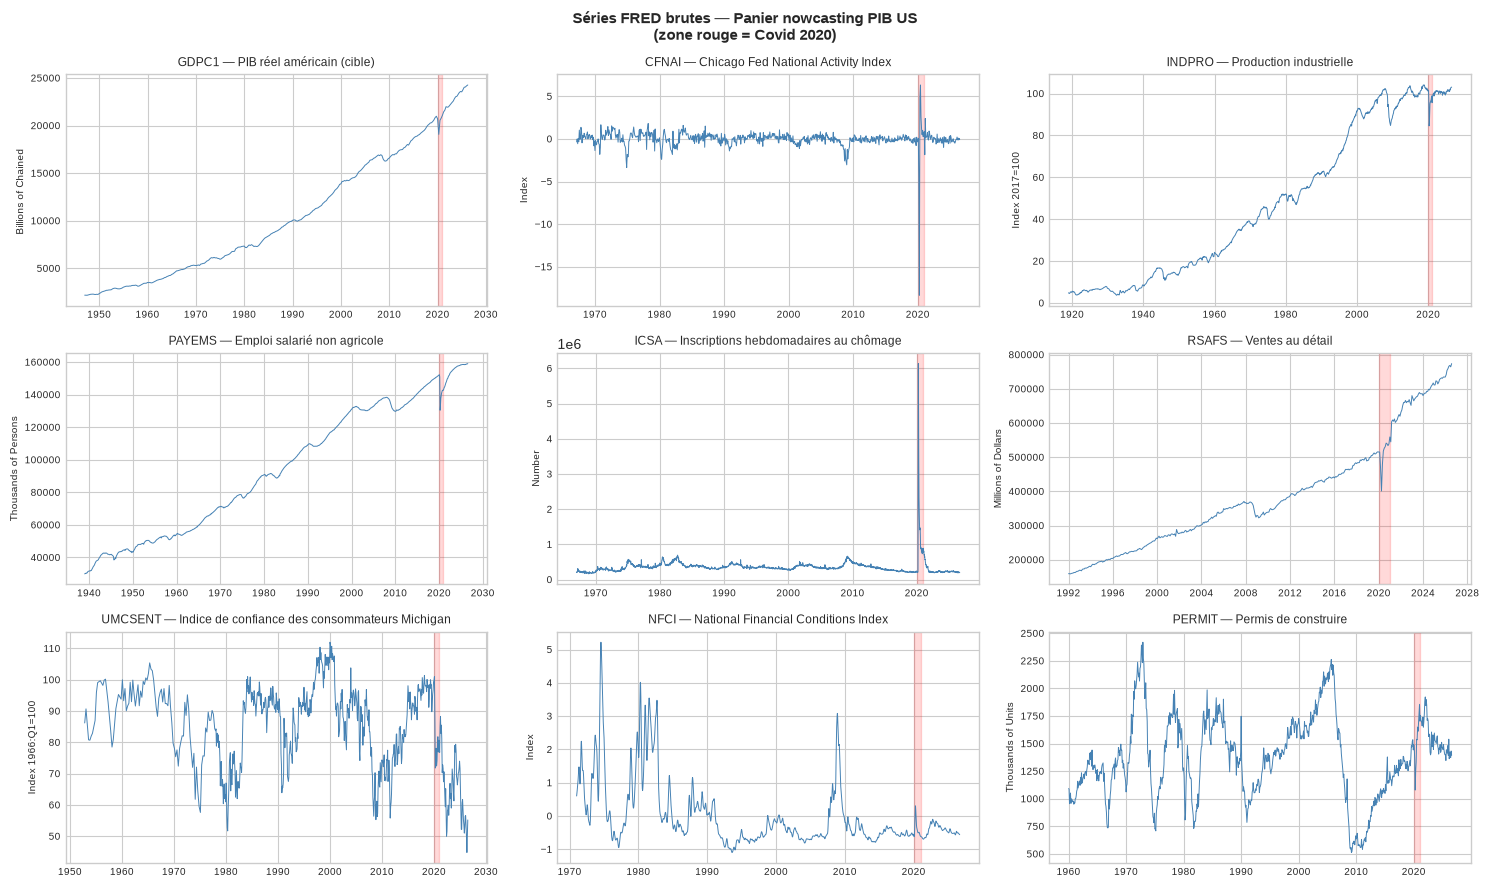

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes_flat = axes.flatten()

for i, (code, spec) in enumerate(FRED_SERIES.items()):
    ax = axes_flat[i]
    s = series_raw[code]
    ax.plot(s.index, s.values, linewidth=0.7, color="steelblue")
    ax.axvspan(
        pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
        alpha=0.15, color="red"
    )
    ax.set_title(f"{code} — {spec.description}", fontsize=8.5)
    ax.set_ylabel(spec.units[:20], fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle(
    "Séries FRED brutes — Panier nowcasting PIB US\n(zone rouge = Covid 2020)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_series_brutes.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Transformations

Chaque série est transformée selon son champ `target_transformation` dans le registry :

| Transformation | Séries | Formule |
|---|---|---|
| `annualized_growth` | GDPC1 | $((x_t/x_{t-1})^4 - 1) \times 100$ |
| `log_diff` | INDPRO, PAYEMS, ICSA, RSAFS, PERMIT | $\ln(x_t) - \ln(x_{t-1})$ |
| `diff` | UMCSENT | $x_t - x_{t-1}$ |
| `none` | CFNAI, NFCI | Aucune (déjà stationnaires) |

In [5]:
series_transformed = {}
for code, spec in FRED_SERIES.items():
    strategy = TRANSFORMATION_MAP[spec.target_transformation]
    series_transformed[code] = strategy.apply(series_raw[code]).dropna()

print("Transformations appliquées.")
for code, s in series_transformed.items():
    print(f"  {code:<10} : {len(s)} obs. | min={s.min():.2f} | max={s.max():.2f} | mean={s.mean():.2f}")

Transformations appliquées.
  GDPC1      : 317 obs. | min=-27.98 | max=34.86 | mean=3.19
  CFNAI      : 713 obs. | min=-18.34 | max=6.33 | mean=0.00
  INDPRO     : 1291 obs. | min=-0.14 | max=0.15 | mean=0.00
  PAYEMS     : 1051 obs. | min=-0.15 | max=0.03 | mean=0.00
  ICSA       : 3114 obs. | min=-0.29 | max=2.37 | mean=-0.00
  RSAFS      : 415 obs. | min=-0.16 | max=0.18 | mean=0.00
  UMCSENT    : 674 obs. | min=-17.30 | max=17.30 | mean=-0.05
  NFCI       : 2906 obs. | min=-1.10 | max=5.22 | mean=-0.00
  PERMIT     : 799 obs. | min=-0.27 | max=0.29 | mean=0.00


### Comparaison brut vs transformé

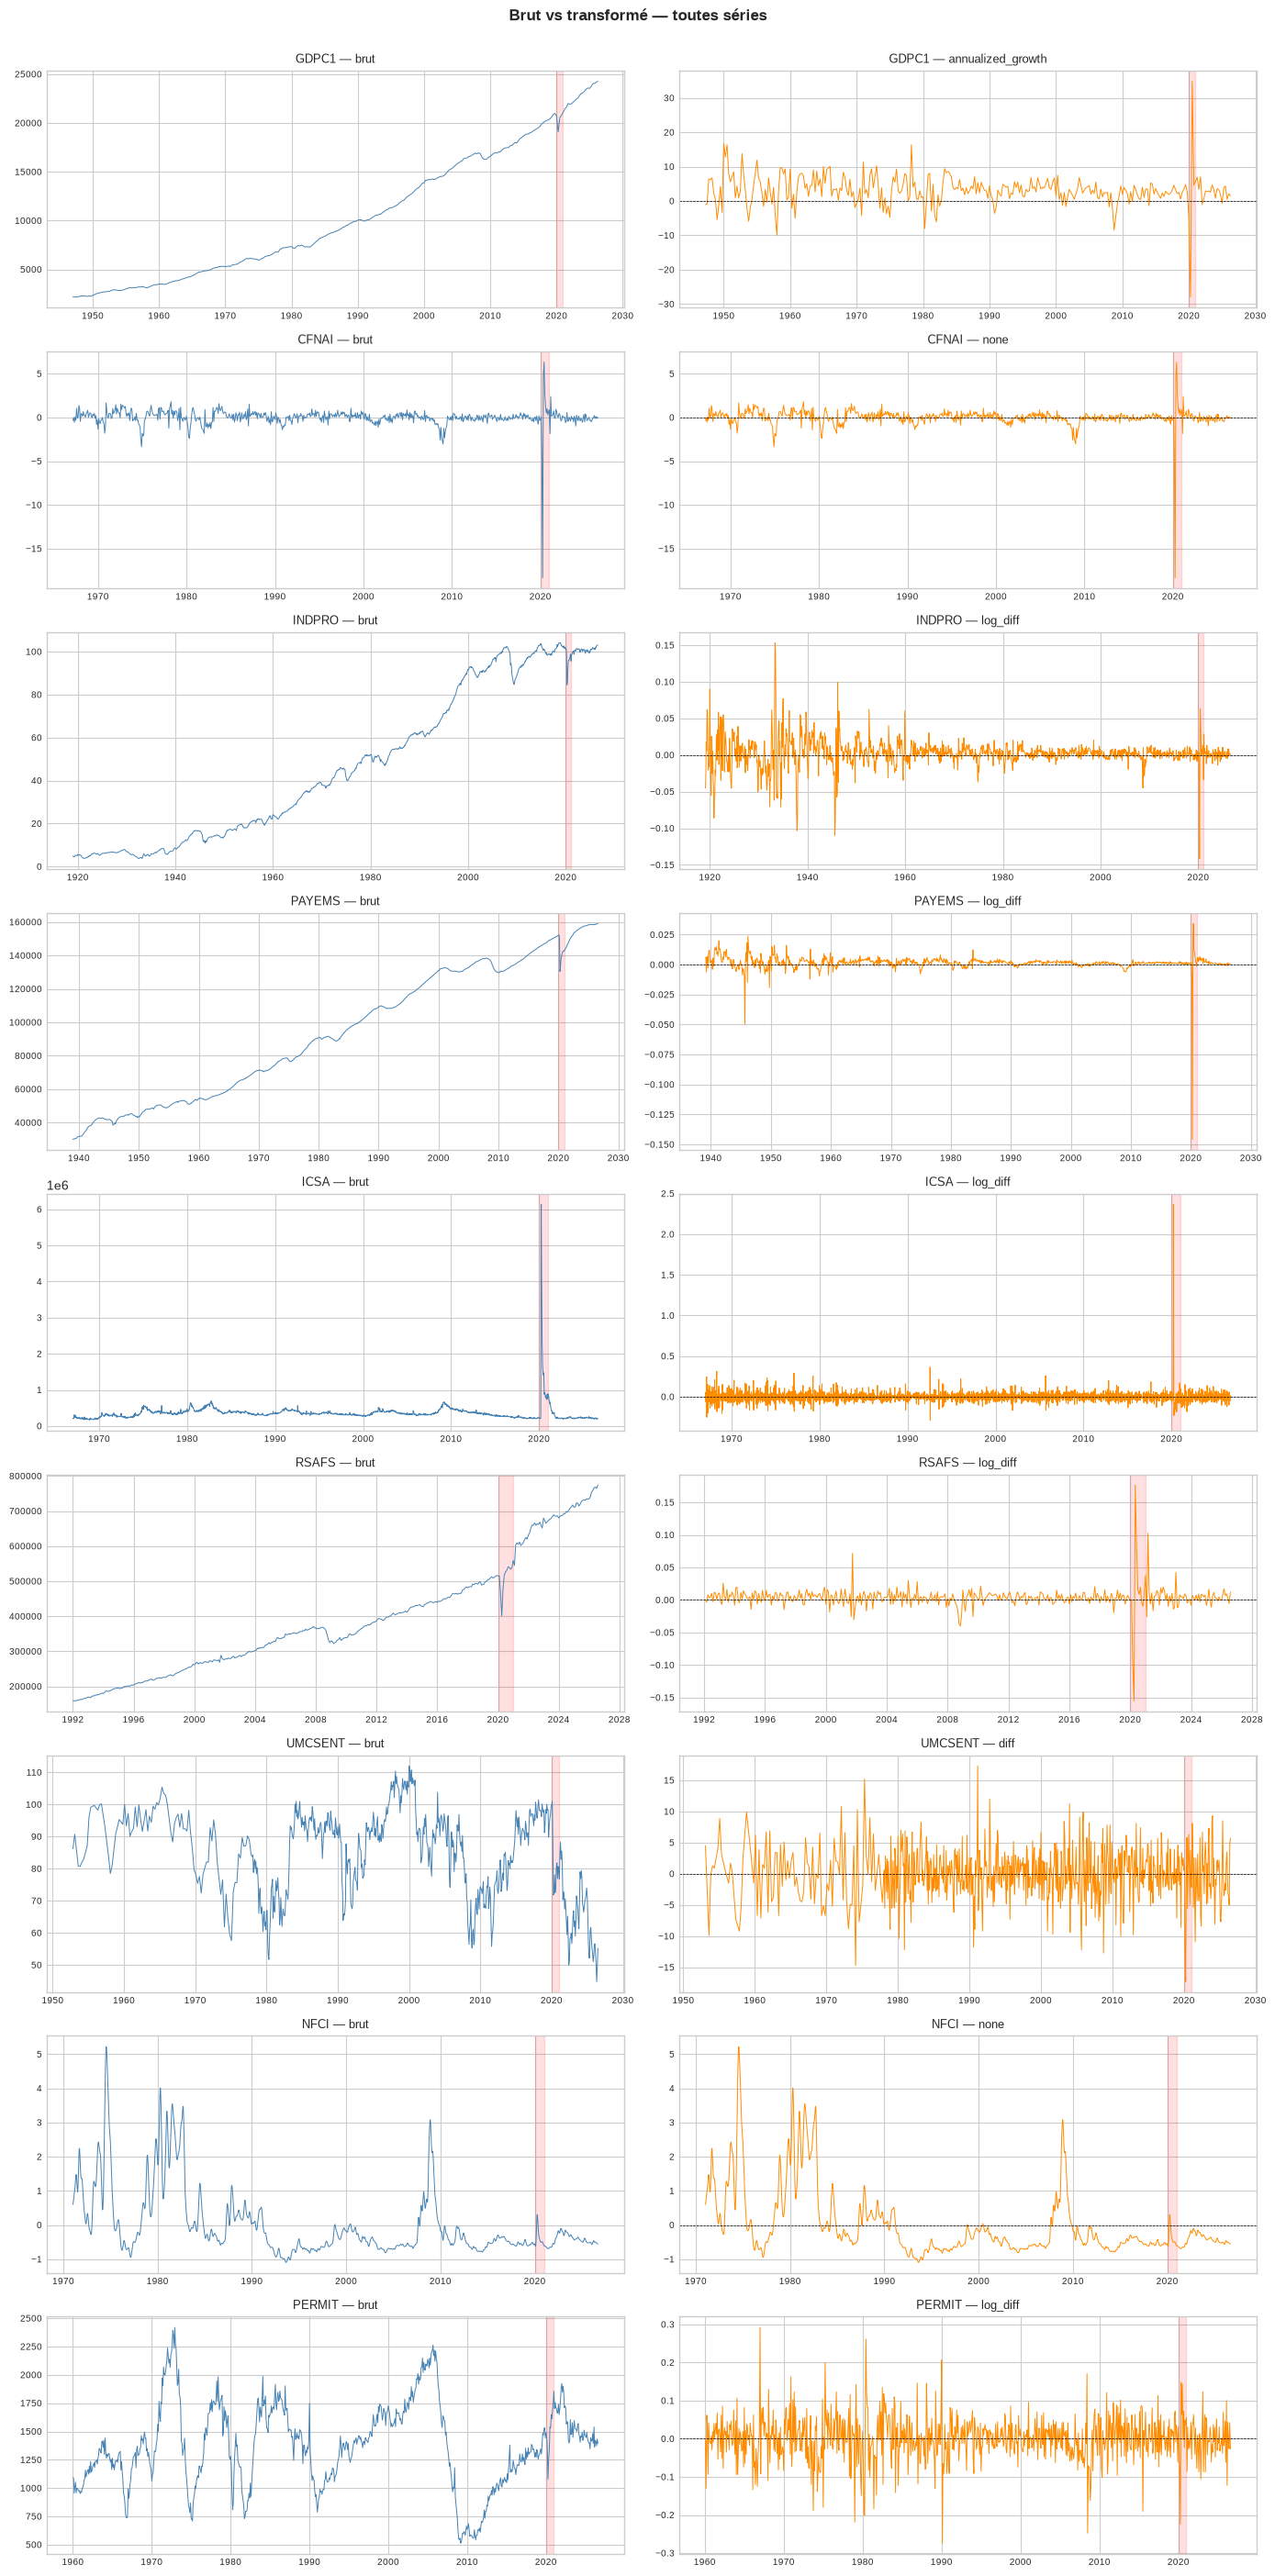

In [6]:
fig, axes = plt.subplots(9, 2, figsize=(14, 28))

for i, (code, spec) in enumerate(FRED_SERIES.items()):
    raw = series_raw[code]
    transf = series_transformed[code]

    axes[i, 0].plot(raw.index, raw.values, linewidth=0.7, color="steelblue")
    axes[i, 0].set_title(f"{code} — brut", fontsize=9)
    axes[i, 0].tick_params(labelsize=7)

    axes[i, 1].plot(transf.index, transf.values, linewidth=0.7, color="darkorange")
    axes[i, 1].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[i, 1].set_title(f"{code} — {spec.target_transformation}", fontsize=9)
    axes[i, 1].tick_params(labelsize=7)

    for ax in axes[i]:
        ax.axvspan(
            pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
            alpha=0.12, color="red"
        )

fig.suptitle("Brut vs transformé — toutes séries", fontsize=12, fontweight="bold", y=1.001)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_brut_vs_transforme.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Tests de stationnarité (ADF + KPSS)

**Rappel des hypothèses :**
- **ADF** : H₀ = racine unitaire (non stationnaire). On veut **rejeter H₀** → p-value < 0.05 ✓
- **KPSS** : H₀ = stationnaire. On veut **ne pas rejeter H₀** → p-value > 0.05 ✓

Une série est considérée stationnaire uniquement quand **les deux tests concordent**.

In [7]:
rows_stat = []
for code, spec in FRED_SERIES.items():
    raw_r = stationarity_report(series_raw[code].dropna())
    trans_r = stationarity_report(series_transformed[code])

    rows_stat.append({
        "Code": code,
        "Transformation": spec.target_transformation,
        "ADF brut (p)": round(raw_r.adf_pvalue, 3),
        "KPSS brut (p)": round(raw_r.kpss_pvalue, 3),
        "Stat. brut": "✓" if raw_r.is_stationary else "✗",
        "ADF transf. (p)": round(trans_r.adf_pvalue, 3),
        "KPSS transf. (p)": round(trans_r.kpss_pvalue, 3),
        "Stat. transf.": "✓" if trans_r.is_stationary else "✗",
    })

df_stat = pd.DataFrame(rows_stat).set_index("Code")
df_stat

/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(
/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(
/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the

/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(
/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(
/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the

/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(
/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/src/quantcube_challenge/preprocessing/stationarity.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_stat, kpss_pvalue, *_ = kpss(


,Transformation,ADF brut (p),KPSS brut (p),Stat. brut,ADF transf. (p),KPSS transf. (p),Stat. transf.
Code,,,,,,,
GDPC1,annualized_growth,1.000,0.010,✗,0.000,0.048,✗
CFNAI,none,0.000,0.100,✓,0.000,0.100,✓
INDPRO,log_diff,0.974,0.010,✗,0.000,0.100,✓
PAYEMS,log_diff,0.942,0.010,✗,0.000,0.018,✗
ICSA,log_diff,0.000,0.100,✓,0.000,0.100,✓
RSAFS,log_diff,0.999,0.010,✗,0.000,0.100,✓
UMCSENT,diff,0.132,0.071,✗,0.000,0.100,✓
NFCI,none,0.003,0.010,✗,0.003,0.010,✗
PERMIT,log_diff,0.001,0.100,✓,0.000,0.100,✓


In [8]:
n_stationary = sum(1 for r in rows_stat if r["Stat. transf."] == "✓")
print(f"{n_stationary}/{len(rows_stat)} séries stationnaires après transformation.")

non_stat = [r["Code"] for r in rows_stat if r["Stat. transf."] != "✓"]
if non_stat:
    print(f"Séries à surveiller : {non_stat}")
else:
    print("Toutes les séries transformées sont stationnaires.")

6/9 séries stationnaires après transformation.
Séries à surveiller : ['GDPC1', 'PAYEMS', 'NFCI']


## 5. Points clés pour le rapport

- **GDPC1 en niveau** : tendance haussière claire → non stationnaire → justifie le choix du taux de croissance annualisé (F04)
- **CFNAI et NFCI** : z-scores par construction, pas de transformation nécessaire
- **ICSA** : hebdomadaire — fréquence la plus élevée du panier, signal économique précoce
- **Covid 2020** : pic/creux extrêmes visibles sur toutes les séries → à traiter en F10
- Le tableau ADF/KPSS sera reproduit dans le rapport final (F12)